In [1]:
import optuna
import os
import matplotlib.pyplot as plt


storage = os.environ["OPTUNA_STORAGE"]
datasets = [
    "cifar100",
    "core50",
    "imagenetr",
]
methods = [
    "linear",
    "lora",
    "ball",
    "replay",
    "gdumb",
    "der",
    "joint",
    "rwalk",
    "l2p",
    "ewc",
    "tball",
]
study_names = set(optuna.get_all_study_names(storage=storage))

studies = {}
for dataset in datasets:
    studies[dataset] = {}
    for method in methods:
        study_name = f"bayescl/hp/{dataset}/{method}"
        if study_name not in study_names:
            continue

        studies[dataset][method] = optuna.load_study(
            study_name=study_name, storage=storage
        ).trials_dataframe()

_MARKERS = ["o", "^", "s", "D"]
COLORS = {method: i for i, method in enumerate(methods)}
MARKER = {method: _MARKERS[i % len(_MARKERS)] for i, method in enumerate(methods)}
CMAP = plt.get_cmap("tab20b")

/local/scratch/antonlee/miniconda3/envs/bayescl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


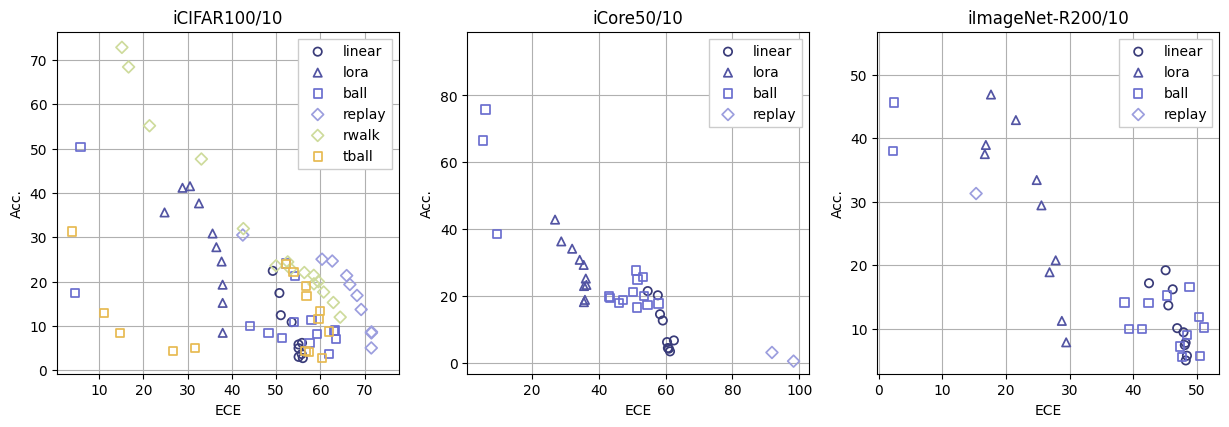

In [2]:
from typing import Dict
import pandas as pd
from matplotlib.axes import Axes

def plot_trials(ax: Axes, trials: Dict[str, pd.DataFrame]):
    ax.grid(True)
    ax.set_axisbelow(True)
    for method, df in trials.items():
        color = CMAP(COLORS[method] % CMAP.N)
        x = df["values_0"] * 100
        y = df["values_1"] * 100
        ax.scatter(x, y, label=method, color=color, marker=MARKER[method], facecolors="none", lw=1.25)
    ax.set_xlabel("ECE")
    ax.set_ylabel("Acc.")

    # aspect ratio 1:1
    ax.set_aspect("equal", adjustable="datalim")
    ax.axis("square")

fig, (ax_cifar100, ax_core50, ax_imagenetr) = plt.subplots(1, 3, figsize=(15, 5))

plot_trials(ax_cifar100, studies["cifar100"])
plot_trials(ax_core50, studies["core50"])
plot_trials(ax_imagenetr, studies["imagenetr"])

ax_cifar100.set_title("iCIFAR100/10")
ax_core50.set_title("iCore50/10")
ax_imagenetr.set_title("iImageNet-R200/10")

ax_cifar100.legend(frameon=True, framealpha=1, fancybox=False)
ax_core50.legend(frameon=True, framealpha=1, fancybox=False)
ax_imagenetr.legend(frameon=True, framealpha=1, fancybox=False)


(0.0, 2.0)

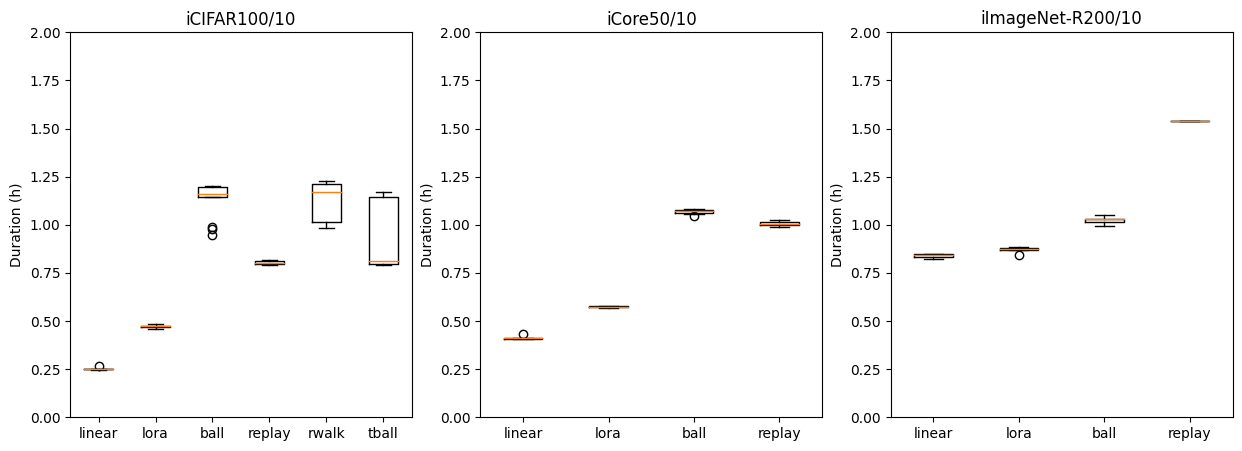

In [3]:
import numpy as np

def boxplot_durations(ax: Axes, trials: Dict[str, pd.DataFrame]):
    # ns to hours
    scale = np.timedelta64(1, "h")
    durations = {}  
    for method, df in trials.items():
        durations[method] = df["duration"].dropna() / scale

    ax.boxplot(durations.values(), labels=durations.keys())
    ax.set_ylabel("Duration (h)")
    ax.set_title("Training Duration")

fig, (ax_duration_cifar100, ax_duration_core50, ax_duration_imagenetr) = plt.subplots(1, 3, figsize=(15, 5))

boxplot_durations(ax_duration_cifar100, studies["cifar100"])
boxplot_durations(ax_duration_core50, studies["core50"])
boxplot_durations(ax_duration_imagenetr, studies["imagenetr"])

ax_duration_cifar100.set_title("iCIFAR100/10")
ax_duration_core50.set_title("iCore50/10")
ax_duration_imagenetr.set_title("iImageNet-R200/10")

ax_duration_cifar100.set_ylim(0, 2)
ax_duration_core50.set_ylim(0, 2)
ax_duration_imagenetr.set_ylim(0, 2)

In [4]:
studies["cifar100"]["linear"]["duration"].to_numpy() / 

SyntaxError: invalid syntax (2111072384.py, line 1)